# Adaptive Low-Latency Fraud Detection in Streaming Financial Systems with LLM-Augmented Explainability

## Notebook 01 — Dataset Understanding

**M.Tech Thesis**

**Objective**

This notebook performs the initial exploration of the benchmark datasets selected for this research. The objective is to understand the structure, quality, and suitability of each dataset before designing the streaming replay framework and adaptive fraud detection pipeline.

### Research Goals

This notebook aims to:

- Discover all available datasets automatically.
- Inspect dataset schemas and metadata.
- Analyze dataset dimensions and storage requirements.
- Identify missing values and feature characteristics.
- Examine class imbalance.
- Understand temporal information available for streaming simulation.
- Produce reusable tables and figures for the thesis.

### Expected Outputs

The notebook will generate:

- Dataset metadata tables
- Schema summaries
- Missing-value reports
- Feature categorization
- Class distribution analysis
- Memory usage statistics
- Publication-quality figures

All outputs will be saved inside the repository for reuse in later experiments and thesis writing.

## 1. Import Required Libraries

In [1]:
from pathlib import Path
import warnings
import json
import random

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

plt.style.use("default")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", None)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Repository Configuration

Rather than hardcoding paths, this notebook automatically detects the repository structure. This ensures that the notebook remains portable across different machines and operating systems.

In [2]:
# Repository Auto Discovery

def find_project_root(start_path: Path) -> Path:
    """
    Locate the project root by searching parent directories for pyproject.toml.

    This allows the notebook to be executed from anywhere inside the repository.
    """

    current = start_path.resolve()

    while current != current.parent:
        if (current / "pyproject.toml").exists():
            return current
        current = current.parent

    raise FileNotFoundError(
        "Could not locate project root. "
        "Ensure the notebook is inside the thesis repository."
    )


PROJECT_ROOT = find_project_root(Path.cwd())

DATASET_DIR = PROJECT_ROOT / "datasets"

OUTPUT_DIR = PROJECT_ROOT / "outputs"

TABLE_DIR = OUTPUT_DIR / "tables"

FIGURE_DIR = OUTPUT_DIR / "figures"

METRIC_DIR = OUTPUT_DIR / "metrics"

for directory in (
    OUTPUT_DIR,
    TABLE_DIR,
    FIGURE_DIR,
    METRIC_DIR,
):
    directory.mkdir(parents=True, exist_ok=True)

print("Repository Configuration")

print(f"Project Root : {PROJECT_ROOT}")
print(f"Dataset Root : {DATASET_DIR}")
print(f"Output Root  : {OUTPUT_DIR}")

Repository Configuration
Project Root : C:\Projects\Thesis
Dataset Root : C:\Projects\Thesis\datasets
Output Root  : C:\Projects\Thesis\outputs


In [3]:
# Export Utilities

def save_table(df: pd.DataFrame, filename: str):
    """
    Save a dataframe as a CSV file inside outputs/tables.
    """

    path = TABLE_DIR / f"{filename}.csv"

    df.to_csv(path, index=False)

    print(f"✓ Table saved: {path.relative_to(PROJECT_ROOT)}")


def save_figure(fig, filename: str):
    """
    Save a matplotlib figure using thesis-quality settings.
    """

    path = FIGURE_DIR / f"{filename}.png"

    fig.savefig(
        path,
        dpi=300,
        bbox_inches="tight",
    )

    print(f"✓ Figure saved: {path.relative_to(PROJECT_ROOT)}")

## 3. Verify Repository Structure

Before loading any dataset, we verify that the expected project structure exists.
This ensures the notebook is being executed inside the correct repository.

In [4]:
required_directories = [
    "configs",
    "datasets",
    "docs",
    "experiments",
    "logs",
    "models",
    "notebooks",
    "outputs",
    "reports",
    "scripts",
    "src",
    "tests",
]

verification = []

for directory in required_directories:

    path = PROJECT_ROOT / directory

    verification.append(
        {
            "Directory": directory,
            "Exists": path.exists()
        }
    )

repo_df = pd.DataFrame(verification)

display(repo_df)

assert repo_df["Exists"].all(), "Repository structure is incomplete."

print("\nRepository structure verified successfully.")

,Directory,Exists
0,configs,True
1,datasets,True
2,docs,True
3,experiments,True
4,logs,True
5,models,True
6,notebooks,True
7,outputs,True
8,reports,True
9,scripts,True



Repository structure verified successfully.


## 4. Dataset Discovery

Instead of manually specifying datasets, the notebook automatically discovers all datasets available under the `datasets/` directory.

This makes the workflow extensible and eliminates hardcoded dataset names.

In [5]:
dataset_directories = sorted(
    [
        d
        for d in DATASET_DIR.iterdir()
        if d.is_dir()
    ]
)

print(f"Datasets discovered: {len(dataset_directories)}\n")

for dataset in dataset_directories:
    print(f"• {dataset.name}")

Datasets discovered: 3

• ieee_cis
• paysim
• ulb


In [6]:
dataset_summary = []

for dataset in dataset_directories:

    files = list(dataset.rglob("*"))

    csv_files = [f for f in files if f.suffix.lower() == ".csv"]

    zip_files = [f for f in files if f.suffix.lower() == ".zip"]

    total_size = sum(
        f.stat().st_size
        for f in files
        if f.is_file()
    )

    dataset_summary.append(
        {
            "Dataset": dataset.name,
            "CSV Files": len(csv_files),
            "ZIP Files": len(zip_files),
            "Total Files": len([f for f in files if f.is_file()]),
            "Size (MB)": round(total_size / (1024**2), 2),
        }
    )

dataset_summary_df = pd.DataFrame(dataset_summary)

display(dataset_summary_df)

,Dataset,CSV Files,ZIP Files,Total Files,Size (MB)
0,ieee_cis,5,0,5,1292.18
1,paysim,1,0,1,470.67
2,ulb,1,0,1,143.84


## 5. Dataset File Inventory

The following table provides a complete inventory of every file currently available inside the repository datasets directory.

This inventory serves as a reproducibility record for future experiments.

In [7]:
inventory = []

for dataset in dataset_directories:

    for file in dataset.rglob("*"):

        if file.is_file():

            inventory.append(
                {
                    "Dataset": dataset.name,
                    "File": file.name,
                    "Extension": file.suffix,
                    "Size (MB)": round(
                        file.stat().st_size / (1024**2),
                        2,
                    ),
                }
            )

inventory_df = pd.DataFrame(inventory)

display(inventory_df)

save_table(
    inventory_df,
    "dataset_inventory",
)

,Dataset,File,Extension,Size (MB)
0,ieee_cis,sample_submission.csv,.csv,5.80
1,ieee_cis,test_identity.csv,.csv,24.60
2,ieee_cis,test_transaction.csv,.csv,584.79
3,ieee_cis,train_identity.csv,.csv,25.30
4,ieee_cis,train_transaction.csv,.csv,651.69
5,paysim,PS_20174392719_1491204439457_log.csv,.csv,470.67
6,ulb,creditcard.csv,.csv,143.84


✓ Table saved: outputs\tables\dataset_inventory.csv


## 6. Dataset Registration

This section automatically discovers every benchmark dataset available inside the repository.

Instead of relying on hardcoded file paths, the notebook constructs a dataset manifest containing file metadata. This improves reproducibility and allows future datasets to be incorporated without modifying notebook logic.

In [8]:
SUPPORTED_DATASETS = {
    "ieee_cis": "IEEE-CIS Fraud Detection",
    "ulb": "ULB Credit Card Fraud Detection",
    "paysim": "PaySim Mobile Money Dataset",
}

SUPPORTED_DATASETS

{'ieee_cis': 'IEEE-CIS Fraud Detection',
 'ulb': 'ULB Credit Card Fraud Detection',
 'paysim': 'PaySim Mobile Money Dataset'}

## 7. Build Dataset Manifest

The following cell scans each registered dataset and records every CSV file available.

The generated manifest serves as a reproducibility record for subsequent experiments.

In [9]:
dataset_manifest = []

for dataset_key, dataset_name in SUPPORTED_DATASETS.items():

    dataset_path = DATASET_DIR / dataset_key

    if not dataset_path.exists():
        raise FileNotFoundError(
            f"Dataset directory not found: {dataset_path}"
        )

    csv_files = sorted(dataset_path.rglob("*.csv"))

    for csv_file in csv_files:

        dataset_manifest.append(
            {
                "Dataset": dataset_key,
                "Description": dataset_name,
                "File": csv_file.name,
                "Relative Path": csv_file.relative_to(PROJECT_ROOT),
                "Size (MB)": round(csv_file.stat().st_size / (1024**2), 2),
            }
        )

manifest_df = pd.DataFrame(dataset_manifest)

display(manifest_df)

save_table(
    manifest_df,
    "dataset_manifest",
)

,Dataset,Description,File,Relative Path,Size (MB)
0,ieee_cis,IEEE-CIS Fraud Detection,sample_submission.csv,datasets\ieee_cis\sample_submission.csv,5.80
1,ieee_cis,IEEE-CIS Fraud Detection,test_identity.csv,datasets\ieee_cis\test_identity.csv,24.60
2,ieee_cis,IEEE-CIS Fraud Detection,test_transaction.csv,datasets\ieee_cis\test_transaction.csv,584.79
3,ieee_cis,IEEE-CIS Fraud Detection,train_identity.csv,datasets\ieee_cis\train_identity.csv,25.30
4,ieee_cis,IEEE-CIS Fraud Detection,train_transaction.csv,datasets\ieee_cis\train_transaction.csv,651.69
5,ulb,ULB Credit Card Fraud Detection,creditcard.csv,datasets\ulb\creditcard.csv,143.84
6,paysim,PaySim Mobile Money Dataset,PS_20174392719_1491204439457_log.csv,datasets\paysim\PS_20174392719_1491204439457_log.csv,470.67


✓ Table saved: outputs\tables\dataset_manifest.csv


In [10]:
print("Dataset Manifest Summary")

print(f"Datasets Registered : {len(SUPPORTED_DATASETS)}")
print(f"CSV Files Discovered : {len(manifest_df)}")
print(
    f"Total Storage (GB) : "
    f"{manifest_df['Size (MB)'].sum()/1024:.2f}"
)

Dataset Manifest Summary
Datasets Registered : 3
CSV Files Discovered : 7
Total Storage (GB) : 1.86


## 8. Generic Dataset Loader

A reusable loader is defined to provide a common interface for all benchmark datasets used throughout this research.

Each dataset is returned as a dictionary of pandas DataFrames keyed by filename.

In [11]:
IGNORE_FILES = {
    "sample_submission.csv",
}


def load_dataset(dataset_name: str):

    dataset_path = DATASET_DIR / dataset_name

    if not dataset_path.exists():
        raise FileNotFoundError(dataset_path)

    dataframes = {}

    csv_files = sorted(dataset_path.rglob("*.csv"))

    for csv_file in csv_files:

        if csv_file.name in IGNORE_FILES:
            continue

        print(f"Loading {csv_file.name}")

        dataframes[csv_file.stem] = pd.read_csv(csv_file)

    return dataframes

## 9. Load Benchmark Datasets

The benchmark datasets are loaded without applying any preprocessing or transformations.

The raw data is preserved to enable unbiased inspection in subsequent analyses.

In [12]:
datasets = {}

for dataset in SUPPORTED_DATASETS:

    datasets[dataset] = load_dataset(dataset)

Loading test_identity.csv
Loading test_transaction.csv
Loading train_identity.csv
Loading train_transaction.csv
Loading creditcard.csv
Loading PS_20174392719_1491204439457_log.csv


## 10. Loaded Dataset Summary

The following table summarizes every DataFrame successfully loaded into memory.

In [13]:
summary = []

for dataset_name, dataset in datasets.items():

    for dataframe_name, dataframe in dataset.items():

        summary.append(
            {
                "Dataset": dataset_name,
                "DataFrame": dataframe_name,
                "Rows": dataframe.shape[0],
                "Columns": dataframe.shape[1],
                "Memory (MB)": round(
                    dataframe.memory_usage(deep=True).sum() / (1024**2),
                    2,
                ),
            }
        )

loaded_summary = pd.DataFrame(summary)

display(loaded_summary)

save_table(
    loaded_summary,
    "loaded_dataset_summary",
)

,Dataset,DataFrame,Rows,Columns,Memory (MB)
0,ieee_cis,test_identity,141907,41,140.08
1,ieee_cis,test_transaction,506691,393,1771.84
2,ieee_cis,train_identity,144233,41,143.14
3,ieee_cis,train_transaction,590540,394,2062.07
4,ulb,creditcard,284807,31,67.36
5,paysim,PS_20174392719_1491204439457_log,6362620,11,1452.57


✓ Table saved: outputs\tables\loaded_dataset_summary.csv


## 11. Dataset Preview

A small preview of each loaded DataFrame is displayed to verify successful loading and provide an initial view of the available information.

Only the first five observations are shown.

In [14]:
for dataset_name, dataset in datasets.items():

    print(SUPPORTED_DATASETS[dataset_name])
    
    for dataframe_name, dataframe in dataset.items():

        print(f"\nDataFrame : {dataframe_name}")
        display(dataframe.head())

IEEE-CIS Fraud Detection

DataFrame : test_identity


,TransactionID,id-01,id-02,id-03,id-04,id-05,id-06,id-07,id-08,id-09,id-10,id-11,id-12,id-13,id-14,id-15,id-16,id-17,id-18,id-19,id-20,id-21,id-22,id-23,id-24,id-25,id-26,id-27,id-28,id-29,id-30,id-31,id-32,id-33,id-34,id-35,id-36,id-37,id-38,DeviceType,DeviceInfo
0,3663586,-45.0,280290.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,100.0,NotFound,27.0,NaN,New,NotFound,225.0,15.0,427.0,563.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,NaN,chrome 67.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,MYA-L13 Build/HUAWEIMYA-L13
1,3663588,0.0,3579.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,100.0,Found,NaN,-300.0,Found,Found,166.0,NaN,542.0,368.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Found,Found,Android 6.0.1,chrome 67.0 for android,24.0,1280x720,match_status:2,T,F,T,T,mobile,LGLS676 Build/MXB48T
2,3663597,-5.0,185210.0,NaN,NaN,1.0,0.0,NaN,NaN,NaN,NaN,100.0,NotFound,52.0,-360.0,New,NotFound,225.0,NaN,271.0,507.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,NaN,ie 11.0 for tablet,NaN,NaN,NaN,F,T,T,F,desktop,Trident/7.0
3,3663601,-45.0,252944.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,100.0,NotFound,27.0,NaN,Found,Found,225.0,15.0,427.0,563.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Found,Found,NaN,chrome 67.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,MYA-L13 Build/HUAWEIMYA-L13
4,3663602,-95.0,328680.0,NaN,NaN,7.0,-33.0,NaN,NaN,NaN,NaN,100.0,NotFound,27.0,NaN,New,NotFound,225.0,15.0,567.0,507.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,NaN,chrome 67.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,SM-G9650 Build/R16NW



DataFrame : test_transaction


,TransactionID,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,3663549,18403224,31.95,W,10409,111.0,150.0,visa,226.0,debit,170.0,87.0,1.0,NaN,gmail.com,NaN,6.0,6.0,0.0,0.0,3.0,4.0,0.0,0.0,6.0,0.0,5.0,1.0,115.0,6.0,419.0,419.0,27.0,398.0,27.0,NaN,NaN,NaN,NaN,418.0,203.0,NaN,NaN,NaN,409.0,T,T,F,NaN,NaN,F,T,T,T,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.000000,47.950001,0.000000,0.000000,47.950001,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.000000,47.950001,0.000000,0.000000,47.950001,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3663550,18403263,49.00,W,4272,111.0,150.0,visa,226.0,debit,299.0,87.0,4.0,NaN,aol.com,NaN,3.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,1.0,1.0,12.0,2.0,149.0,149.0,7.0,634.0,7.0,NaN,NaN,NaN,NaN,231.0,634.0,NaN,NaN,NaN,634.0,T,F,F,M0,NaN,F,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0


DataFrame : train_identity


...

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,M0,T,T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,

ULB Credit Card Fraud Detection

DataFrame : creditcard


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


PaySim Mobile Money Dataset

DataFrame : PS_20174392719_1491204439457_log


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


## 12. Dataset Dimensions

This section summarizes the structural characteristics of each benchmark dataset, including the number of observations, features, and approximate memory usage.

These characteristics provide an initial understanding of the scale and complexity of the datasets before any preprocessing or modelling is performed.

In [15]:
dimension_summary = []

for dataset_name, dataset in datasets.items():

    for dataframe_name, dataframe in dataset.items():

        memory_mb = (
            dataframe.memory_usage(deep=True)
            .sum()
            / (1024 ** 2)
        )

        dimension_summary.append(
            {
                "Dataset": SUPPORTED_DATASETS[dataset_name],
                "DataFrame": dataframe_name,
                "Rows": dataframe.shape[0],
                "Columns": dataframe.shape[1],
                "Memory (MB)": round(memory_mb, 2),
            }
        )

dimension_df = pd.DataFrame(dimension_summary)

display(dimension_df)

save_table(
    dimension_df,
    "dataset_dimensions",
)

,Dataset,DataFrame,Rows,Columns,Memory (MB)
0,IEEE-CIS Fraud Detection,test_identity,141907,41,140.08
1,IEEE-CIS Fraud Detection,test_transaction,506691,393,1771.84
2,IEEE-CIS Fraud Detection,train_identity,144233,41,143.14
3,IEEE-CIS Fraud Detection,train_transaction,590540,394,2062.07
4,ULB Credit Card Fraud Detection,creditcard,284807,31,67.36
5,PaySim Mobile Money Dataset,PS_20174392719_1491204439457_log,6362620,11,1452.57


✓ Table saved: outputs\tables\dataset_dimensions.csv


## 13. Dataset Size Comparison

The total number of observations varies considerably across the selected benchmark datasets.

This comparison highlights the relative scale of each dataset and its suitability for large-scale experimentation.

✓ Figure saved: outputs\figures\dataset_size_comparison.png


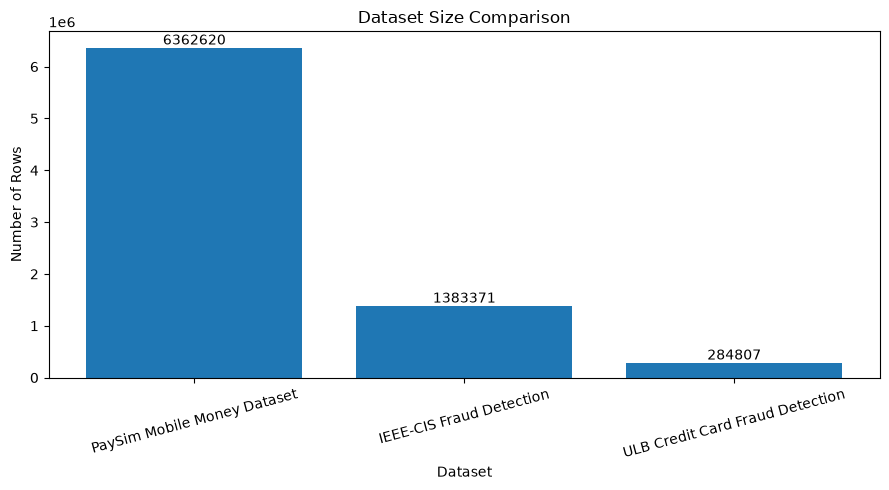

In [16]:
rows_df = (
    dimension_df
    .groupby("Dataset")["Rows"]
    .sum()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(9,5))

bars = ax.bar(
    rows_df.index,
    rows_df.values,
)

ax.set_title("Dataset Size Comparison")

ax.set_ylabel("Number of Rows")

ax.set_xlabel("Dataset")

ax.bar_label(
    bars,
    fmt="%.0f",
)

plt.xticks(rotation=15)

plt.tight_layout()

save_figure(
    fig,
    "dataset_size_comparison",
)

plt.show()

## 14. Schema Complexity Comparison

The number of features provides an indication of the structural complexity of each benchmark dataset.

Datasets containing larger feature spaces generally require more sophisticated preprocessing and feature engineering.

✓ Figure saved: outputs\figures\schema_complexity_comparison.png


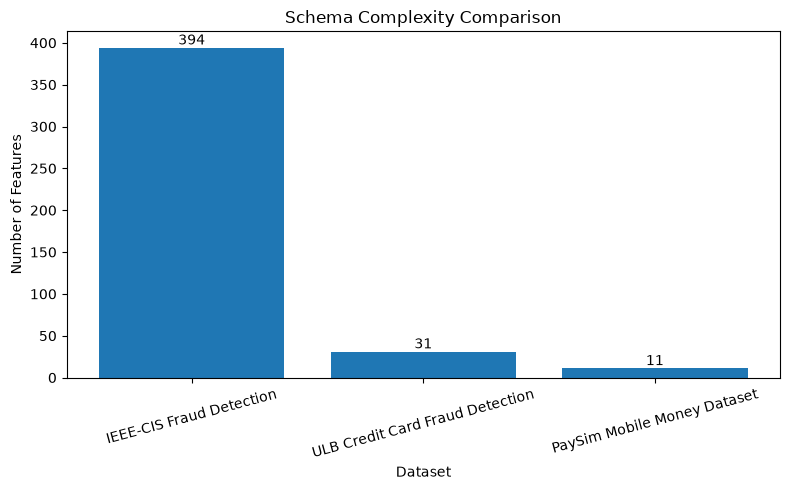

In [17]:
column_df = (
    dimension_df
    .groupby("Dataset")["Columns"]
    .max()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8,5))

bars = ax.bar(
    column_df.index,
    column_df.values,
)

ax.set_title("Schema Complexity Comparison")

ax.set_ylabel("Number of Features")

ax.set_xlabel("Dataset")

ax.bar_label(
    bars,
)

plt.xticks(rotation=15)

plt.tight_layout()

save_figure(
    fig,
    "schema_complexity_comparison",
)

plt.show()

## 15. Column Metadata

The metadata of every feature is extracted to provide a complete overview of the schema associated with each benchmark dataset.

For each feature, the dataset, DataFrame, column name, inferred data type, and percentage of missing values are recorded.

This metadata will support later preprocessing and feature engineering stages.

In [18]:
metadata = []

for dataset_name, dataset in datasets.items():

    for dataframe_name, dataframe in dataset.items():

        for column in dataframe.columns:

            metadata.append(
                {
                    "Dataset": SUPPORTED_DATASETS[dataset_name],
                    "DataFrame": dataframe_name,
                    "Column": column,
                    "Data Type": str(dataframe[column].dtype),
                    "Missing (%)": round(
                        dataframe[column].isna().mean() * 100,
                        2,
                    ),
                }
            )

metadata_df = pd.DataFrame(metadata)

display(metadata_df)

save_table(
    metadata_df,
    "column_metadata",
)

,Dataset,DataFrame,Column,Data Type,Missing (%)
0,IEEE-CIS Fraud Detection,test_identity,TransactionID,int64,0.00
1,IEEE-CIS Fraud Detection,test_identity,id-01,float64,0.00
2,IEEE-CIS Fraud Detection,test_identity,id-02,float64,3.47
3,IEEE-CIS Fraud Detection,test_identity,id-03,float64,53.15
4,IEEE-CIS Fraud Detection,test_identity,id-04,float64,53.15
...,...,...,...,...,...
906,PaySim Mobile Money Dataset,PS_20174392719_1491204439457_log,nameDest,str,0.00
907,PaySim Mobile Money Dataset,PS_20174392719_1491204439457_log,oldbalanceDest,float64,0.00
908,PaySim Mobile Money Dataset,PS_20174392719_1491204439457_log,newbalanceDest,float64,0.00
909,PaySim Mobile Money Dataset,PS_20174392719_1491204439457_log,isFraud,int64,0.00


✓ Table saved: outputs\tables\column_metadata.csv


## 16. Data Type Distribution

The distribution of feature data types provides an overview of the structural composition of the benchmark datasets and offers an initial indication of the preprocessing techniques that may be required.

In [19]:
datatype_summary = (
    metadata_df
    .groupby("Data Type")
    .size()
    .reset_index(name="Count")
    .sort_values(
        "Count",
        ascending=False,
    )
)

display(datatype_summary)

save_table(
    datatype_summary,
    "datatype_summary",
)

,Data Type,Count
0,float64,833
2,str,65
1,int64,13


✓ Table saved: outputs\tables\datatype_summary.csv


## 17. Data Type Visualization

The following visualization summarizes the overall distribution of feature data types across all benchmark datasets.

✓ Figure saved: outputs\figures\datatype_distribution.png


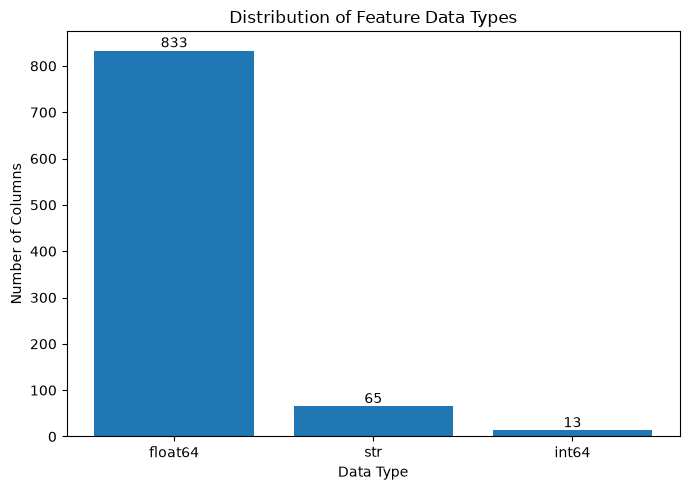

In [20]:
fig, ax = plt.subplots(figsize=(7,5))

bars = ax.bar(
    datatype_summary["Data Type"],
    datatype_summary["Count"],
)

ax.set_title("Distribution of Feature Data Types")

ax.set_xlabel("Data Type")

ax.set_ylabel("Number of Columns")

ax.bar_label(
    bars,
)

plt.tight_layout()

save_figure(
    fig,
    "datatype_distribution",
)

plt.show()

## 18. Structural Observations

The structural analysis highlights notable differences among the benchmark datasets.

- **IEEE-CIS Fraud Detection** contains the largest feature space, making it suitable for evaluating feature engineering techniques and adaptive learning methods in high-dimensional environments.

- **ULB Credit Card Fraud Detection** provides a compact and well-established benchmark that is appropriate for controlled experimentation and baseline evaluation.

- **PaySim Mobile Money Dataset** contains substantially more transaction records while maintaining a relatively simple schema, making it particularly suitable for streaming simulation and concept drift experiments.

The complementary characteristics of these benchmark datasets provide a comprehensive experimental foundation for evaluating adaptive fraud detection methods under varying levels of data complexity and scale.

## 19. Missing Value Analysis

Missing values are a common characteristic of real-world fraud detection datasets and can influence both preprocessing strategies and model performance.

This section quantifies the extent of missing information across all benchmark datasets without applying any imputation or data cleaning.

In [21]:
missing_summary = []

missing_details = []

for dataset_name, dataset in datasets.items():

    for dataframe_name, dataframe in dataset.items():

        total_missing = dataframe.isna().sum().sum()

        total_cells = dataframe.shape[0] * dataframe.shape[1]

        missing_summary.append(
            {
                "Dataset": SUPPORTED_DATASETS[dataset_name],
                "DataFrame": dataframe_name,
                "Total Missing": int(total_missing),
                "Missing (%)": round(
                    (total_missing / total_cells) * 100,
                    2,
                ),
            }
        )

        column_missing = (
            dataframe
            .isna()
            .mean()
            .mul(100)
            .round(2)
        )

        for column, value in column_missing.items():

            missing_details.append(
                {
                    "Dataset": SUPPORTED_DATASETS[dataset_name],
                    "DataFrame": dataframe_name,
                    "Column": column,
                    "Missing (%)": value,
                }
            )

missing_summary_df = pd.DataFrame(missing_summary)

missing_details_df = pd.DataFrame(missing_details)

display(missing_summary_df)

save_table(
    missing_summary_df,
    "missing_summary",
)

save_table(
    missing_details_df,
    "missing_by_column",
)

,Dataset,DataFrame,Total Missing,Missing (%)
0,IEEE-CIS Fraud Detection,test_identity,2105385,36.19
1,IEEE-CIS Fraud Detection,test_transaction,73490163,36.91
2,IEEE-CIS Fraud Detection,train_identity,2104107,35.58
3,IEEE-CIS Fraud Detection,train_transaction,95566686,41.07
4,ULB Credit Card Fraud Detection,creditcard,0,0.00
5,PaySim Mobile Money Dataset,PS_20174392719_1491204439457_log,0,0.00


✓ Table saved: outputs\tables\missing_summary.csv
✓ Table saved: outputs\tables\missing_by_column.csv


## 20. Dataset-Level Missing Values

The following figure compares the overall percentage of missing values across the benchmark datasets.

✓ Figure saved: outputs\figures\overall_missing_values.png


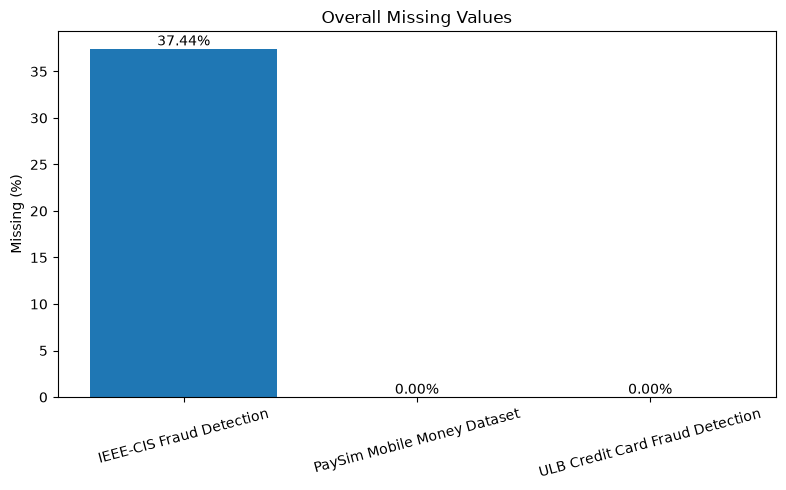

In [22]:
plot_df = (
    missing_summary_df
    .groupby("Dataset")["Missing (%)"]
    .mean()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8,5))

bars = ax.bar(
    plot_df.index,
    plot_df.values,
)

ax.bar_label(
    bars,
    fmt="%.2f%%",
)

ax.set_title("Overall Missing Values")

ax.set_ylabel("Missing (%)")

plt.xticks(rotation=15)

plt.tight_layout()

save_figure(
    fig,
    "overall_missing_values",
)

plt.show()

## 21. Columns with Missing Values

Only features containing at least one missing value are reported.

In [23]:
columns_with_missing = (
    missing_details_df[
        missing_details_df["Missing (%)"] > 0
    ]
    .sort_values(
        "Missing (%)",
        ascending=False,
    )
)

display(columns_with_missing)

save_table(
    columns_with_missing,
    "columns_with_missing",
)

,Dataset,DataFrame,Column,Missing (%)
458,IEEE-CIS Fraud Detection,train_identity,id_24,96.71
24,IEEE-CIS Fraud Detection,test_identity,id-24,96.66
25,IEEE-CIS Fraud Detection,test_identity,id-25,96.45
459,IEEE-CIS Fraud Detection,train_identity,id_25,96.44
26,IEEE-CIS Fraud Detection,test_identity,id-26,96.44
...,...,...,...,...
639,IEEE-CIS Fraud Detection,train_transaction,V110,0.05
640,IEEE-CIS Fraud Detection,train_transaction,V111,0.05
641,IEEE-CIS Fraud Detection,train_transaction,V112,0.05
642,IEEE-CIS Fraud Detection,train_transaction,V113,0.05


✓ Table saved: outputs\tables\columns_with_missing.csv


## 22. Duplicate Analysis

Duplicate observations may arise due to repeated data collection, aggregation processes, or recording errors. Their presence can bias statistical analyses and machine learning models by overrepresenting certain patterns.

This section quantifies duplicate records across the benchmark datasets without performing any deduplication.

In [24]:
duplicate_summary = []

for dataset_name, dataset in datasets.items():

    for dataframe_name, dataframe in dataset.items():

        duplicate_count = dataframe.duplicated().sum()

        duplicate_summary.append(
            {
                "Dataset": SUPPORTED_DATASETS[dataset_name],
                "DataFrame": dataframe_name,
                "Duplicate Rows": int(duplicate_count),
                "Duplicate (%)": round(
                    duplicate_count / len(dataframe) * 100,
                    4,
                ),
            }
        )

duplicate_df = pd.DataFrame(duplicate_summary)

display(duplicate_df)

save_table(
    duplicate_df,
    "duplicate_summary",
)

,Dataset,DataFrame,Duplicate Rows,Duplicate (%)
0,IEEE-CIS Fraud Detection,test_identity,0,0.0000
1,IEEE-CIS Fraud Detection,test_transaction,0,0.0000
2,IEEE-CIS Fraud Detection,train_identity,0,0.0000
3,IEEE-CIS Fraud Detection,train_transaction,0,0.0000
4,ULB Credit Card Fraud Detection,creditcard,1081,0.3796
5,PaySim Mobile Money Dataset,PS_20174392719_1491204439457_log,0,0.0000


✓ Table saved: outputs\tables\duplicate_summary.csv


## 23. Duplicate Record Comparison

The following visualization compares the proportion of duplicate records across the benchmark datasets.

✓ Figure saved: outputs\figures\duplicate_comparison.png


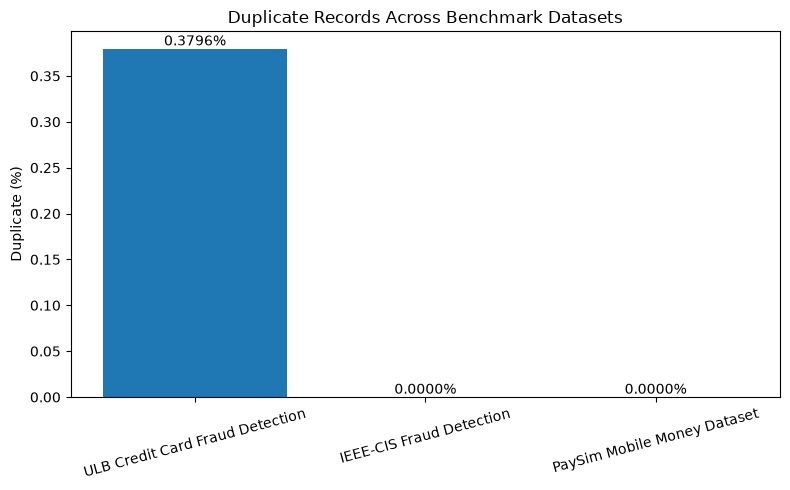

In [25]:
duplicate_plot = (
    duplicate_df
    .groupby("Dataset")["Duplicate (%)"]
    .mean()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    duplicate_plot.index,
    duplicate_plot.values,
)

ax.set_title("Duplicate Records Across Benchmark Datasets")

ax.set_ylabel("Duplicate (%)")

ax.bar_label(
    bars,
    fmt="%.4f%%",
)

plt.xticks(rotation=15)

plt.tight_layout()

save_figure(
    fig,
    "duplicate_comparison",
)

plt.show()

## 24. Feature Cardinality Analysis

Feature cardinality refers to the number of distinct values present in a feature. It provides insight into the diversity of information contained within the dataset and helps identify identifier-like attributes, categorical variables, and constant features.

This section summarizes the cardinality characteristics of all benchmark datasets without modifying the underlying data.

In [26]:
cardinality_summary = []

feature_cardinality = []

for dataset_name, dataset in datasets.items():

    for dataframe_name, dataframe in dataset.items():

        unique_counts = dataframe.nunique(dropna=False)

        constant_features = (unique_counts == 1).sum()

        binary_features = (unique_counts == 2).sum()

        low_cardinality = ((unique_counts >= 3) & (unique_counts <= 20)).sum()

        high_cardinality = (unique_counts > 20).sum()

        cardinality_summary.append(
            {
                "Dataset": SUPPORTED_DATASETS[dataset_name],
                "DataFrame": dataframe_name,
                "Features": dataframe.shape[1],
                "Constant Features": int(constant_features),
                "Binary Features": int(binary_features),
                "Low-Cardinality Features (3–20)": int(low_cardinality),
                "High-Cardinality Features (>20)": int(high_cardinality),
                "Maximum Cardinality": int(unique_counts.max()),
            }
        )

        for column, value in unique_counts.items():

            feature_cardinality.append(
                {
                    "Dataset": SUPPORTED_DATASETS[dataset_name],
                    "DataFrame": dataframe_name,
                    "Column": column,
                    "Unique Values": int(value),
                }
            )

cardinality_df = pd.DataFrame(cardinality_summary)

feature_cardinality_df = pd.DataFrame(feature_cardinality)

display(cardinality_df)

save_table(
    cardinality_df,
    "cardinality_summary",
)

save_table(
    feature_cardinality_df,
    "feature_cardinality",
)

,Dataset,DataFrame,Features,Constant Features,Binary Features,Low-Cardinality Features (3–20),High-Cardinality Features (>20),Maximum Cardinality
0,IEEE-CIS Fraud Detection,test_identity,41,0,1,16,24,141907
1,IEEE-CIS Fraud Detection,test_transaction,393,1,0,149,243,506691
2,IEEE-CIS Fraud Detection,train_identity,41,0,1,16,24,144233
3,IEEE-CIS Fraud Detection,train_transaction,394,0,1,147,246,590540
4,ULB Credit Card Fraud Detection,creditcard,31,0,1,0,30,275663
5,PaySim Mobile Money Dataset,PS_20174392719_1491204439457_log,11,0,2,1,8,6353307


✓ Table saved: outputs\tables\cardinality_summary.csv
✓ Table saved: outputs\tables\feature_cardinality.csv


## 25. Cardinality Comparison

The following visualization summarizes the number of high-cardinality features within each benchmark dataset.

High-cardinality attributes generally contain a large number of distinct values and often require specialized preprocessing techniques during model development.

✓ Figure saved: outputs\figures\high_cardinality_features.png


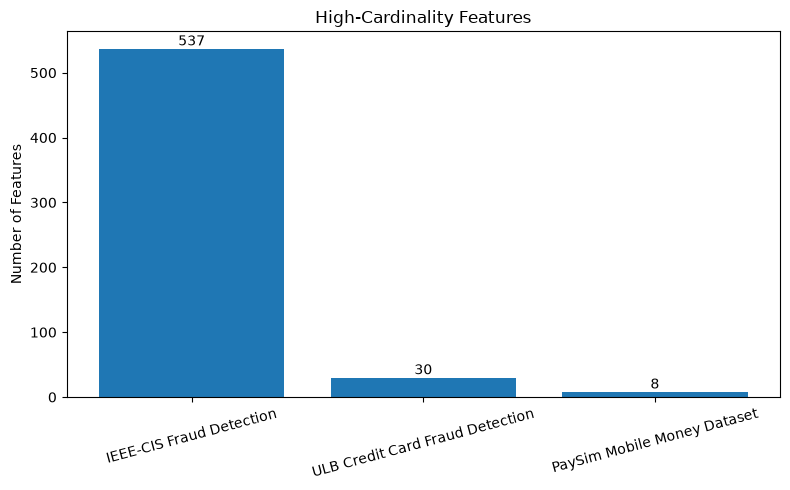

In [28]:
plot_df = (
    cardinality_df
    .groupby("Dataset")["High-Cardinality Features (>20)"]
    .sum()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8,5))

bars = ax.bar(
    plot_df.index,
    plot_df.values,
)

ax.set_title("High-Cardinality Features")

ax.set_ylabel("Number of Features")

ax.bar_label(
    bars,
)

plt.xticks(rotation=15)

plt.tight_layout()

save_figure(
    fig,
    "high_cardinality_features",
)

plt.show()

## 26. Target Variable Analysis

Understanding the class distribution of fraudulent and legitimate transactions is essential for selecting suitable evaluation metrics and learning strategies.

This section examines the target variable for datasets containing fraud labels.

In [29]:
target_summary = []

TARGET_COLUMNS = [
    "isFraud",
    "Class",
]

for dataset_name, dataset in datasets.items():

    for dataframe_name, dataframe in dataset.items():

        target_column = None

        for column in TARGET_COLUMNS:

            if column in dataframe.columns:

                target_column = column
                break

        if target_column is None:
            continue

        counts = dataframe[target_column].value_counts().sort_index()

        total = len(dataframe)

        for label, count in counts.items():

            target_summary.append(
                {
                    "Dataset": SUPPORTED_DATASETS[dataset_name],
                    "DataFrame": dataframe_name,
                    "Target": target_column,
                    "Class": label,
                    "Count": int(count),
                    "Percentage": round(
                        count / total * 100,
                        4,
                    ),
                }
            )

target_df = pd.DataFrame(target_summary)

display(target_df)

save_table(
    target_df,
    "target_distribution",
)

,Dataset,DataFrame,Target,Class,Count,Percentage
0,IEEE-CIS Fraud Detection,train_transaction,isFraud,0,569877,96.5010
1,IEEE-CIS Fraud Detection,train_transaction,isFraud,1,20663,3.4990
2,ULB Credit Card Fraud Detection,creditcard,Class,0,284315,99.8273
3,ULB Credit Card Fraud Detection,creditcard,Class,1,492,0.1727
4,PaySim Mobile Money Dataset,PS_20174392719_1491204439457_log,isFraud,0,6354407,99.8709
5,PaySim Mobile Money Dataset,PS_20174392719_1491204439457_log,isFraud,1,8213,0.1291


✓ Table saved: outputs\tables\target_distribution.csv


## 27. Target Class Distribution

The following visualization compares the proportion of fraudulent and legitimate transactions across the benchmark datasets containing class labels.

✓ Figure saved: outputs\figures\class_distribution.png


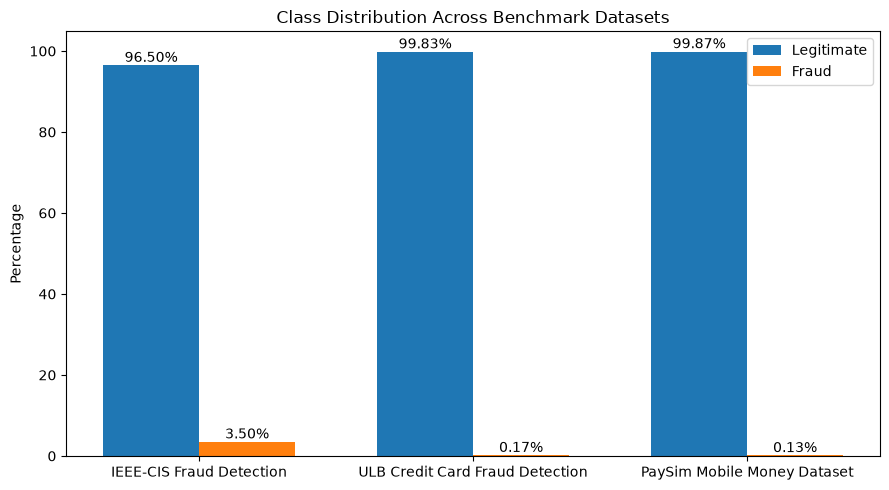

In [30]:
plot_df = target_df.copy()

plot_df["Class"] = plot_df["Class"].astype(str)

datasets_with_target = plot_df["Dataset"].unique()

fig, ax = plt.subplots(figsize=(9,5))

bar_width = 0.35

x = np.arange(len(datasets_with_target))

legitimate = []
fraud = []

for dataset in datasets_with_target:

    subset = plot_df[plot_df["Dataset"] == dataset]

    legitimate.append(
        subset.loc[
            subset["Class"] == "0",
            "Percentage",
        ].values[0]
    )

    fraud.append(
        subset.loc[
            subset["Class"] == "1",
            "Percentage",
        ].values[0]
    )

bars1 = ax.bar(
    x - bar_width/2,
    legitimate,
    width=bar_width,
    label="Legitimate",
)

bars2 = ax.bar(
    x + bar_width/2,
    fraud,
    width=bar_width,
    label="Fraud",
)

ax.set_xticks(x)

ax.set_xticklabels(datasets_with_target)

ax.set_ylabel("Percentage")

ax.set_title("Class Distribution Across Benchmark Datasets")

ax.legend()

ax.bar_label(
    bars1,
    fmt="%.2f%%",
)

ax.bar_label(
    bars2,
    fmt="%.2f%%",
)

plt.tight_layout()

save_figure(
    fig,
    "class_distribution",
)

plt.show()

## 28. Data Quality Observations

The data quality assessment reveals distinct characteristics across the selected benchmark datasets, highlighting their complementary roles in fraud detection research.

- The **IEEE-CIS Fraud Detection** dataset exhibits substantial missing values, with approximately **41.07%** missing entries in the training transaction data and **35.58%** in the training identity data. This level of sparsity reflects the incompleteness commonly encountered in real-world financial transaction systems, where customer identity and device-related information may not always be available.

- In contrast, the **ULB Credit Card Fraud Detection** and **PaySim Mobile Money** datasets contain no missing values, providing cleaner benchmark datasets for controlled experimentation and baseline model evaluation.

- Duplicate analysis indicates that the IEEE-CIS and PaySim datasets contain no duplicate records, whereas the ULB dataset contains **1,081 duplicate transactions (0.3796%)**. As this duplication is minimal and the ULB duplicates are well documented in the literature, it is retained in the original dataset during this exploratory stage.

- Feature cardinality analysis demonstrates considerable structural diversity across the datasets. The IEEE-CIS benchmark contains numerous high-cardinality attributes, while the PaySim dataset exhibits extremely high transaction-level cardinality due to its large number of unique transactional values. These characteristics indicate that appropriate feature engineering and encoding strategies will be required during subsequent preprocessing stages.

- Target variable analysis confirms severe class imbalance across all benchmark datasets. Fraudulent transactions constitute approximately **3.50%** of IEEE-CIS, **0.17%** of ULB, and **0.13%** of PaySim observations. Consequently, model evaluation will rely on imbalance-aware performance metrics, including Precision, Recall, F1-score, ROC-AUC, and PR-AUC, rather than overall accuracy alone.

Overall, the selected benchmark datasets provide complementary characteristics in terms of data completeness, sparsity, feature complexity, and class imbalance, making them well suited for evaluating adaptive fraud detection methods under diverse real-world conditions.